复制源模型（除了输出层），在源模型原有参数的基础上进行微调

In [1]:
import d2l.torch as d2l
# 注册热狗数据集
d2l.DATA_HUB['hotdog'] = (d2l.DATA_URL + 'hotdog.zip', 'fba480ffa8aa7e0febbb511d181409f899b9baa5')
# 自动下载+解压，返回解压后的根目录
data_dir = d2l.download_extract('hotdog')
print("数据集解压路径：", data_dir)
# 运行完成后，复制打印出的路径，之后本段全部注释

数据集解压路径： ../data\hotdog


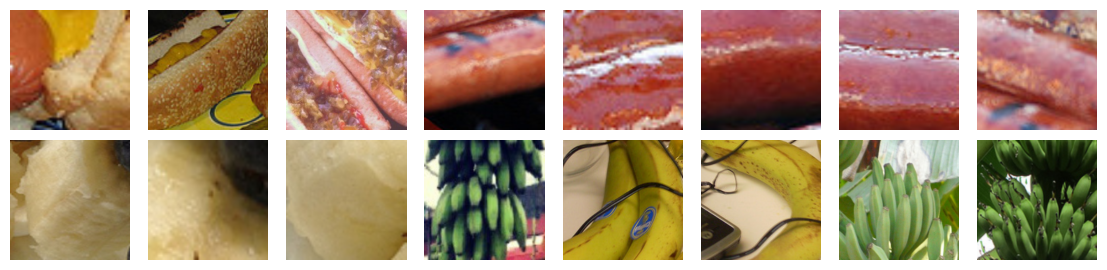

In [4]:
import os
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import time
from collections import defaultdict

data_dir = r"C:\Users\17934\Desktop\MachineLearning\Program\DataSet\Figure\hotdog"

def build_hotdog_dataloaders(data_dir, batch_size, train_augs, test_augs, num_workers=0):
    """构建热狗数据集的训练/测试DataLoader"""
    train_dataset = torchvision.datasets.ImageFolder(
        root=os.path.join(data_dir, "train"),
        transform=train_augs
    )
    test_dataset = torchvision.datasets.ImageFolder(
        root=os.path.join(data_dir, "test"),
        transform=test_augs
    )
    
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, drop_last=False
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, drop_last=False
    )
    return train_loader, test_loader

# 1. 标准化与图像增广
normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_augs = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
])

test_augs = transforms.Compose([
    transforms.Resize([256, 256]),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize
])

# 2. ImageFolder读取数据集
train_dataset = torchvision.datasets.ImageFolder(
    root=os.path.join(data_dir, "train"),
    transform=train_augs
)
test_dataset = torchvision.datasets.ImageFolder(
    root=os.path.join(data_dir, "test"),
    transform=test_augs
)

# 3. 构建 DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# 4. 可视化
def show_images(img_list, n_rows, n_cols, scale=1.0):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * scale, n_rows * scale))
    axes = axes.flatten()
    for idx, img in enumerate(img_list):
        # 区分PIL原图 / tensor张量
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            # tensor反标准化还原原图
            mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3,1,1)
            std = torch.tensor([0.229, 0.224, 0.225]).reshape(3,1,1)
            arr = img * std + mean
            arr = arr.permute(1,2,0).cpu().numpy()
        axes[idx].imshow(np.clip(arr,0,1))
        axes[idx].axis("off")
    plt.tight_layout()
    plt.show()

hotdogs = [train_dataset[i][0] for i in range(8)]
not_hotdogs = [train_dataset[-i - 1][0] for i in range(8)]
show_images(hotdogs + not_hotdogs, n_rows=2, n_cols=8, scale=1.4)

In [5]:
def get_device():
    if torch.cuda.is_available():
        return [torch.device(f'cuda:{i}') for i in range(torch.cuda.device_count())]
    return [torch.device('cpu')]

class Timer:
    def __init__(self):
        self.total_time = 0.0
        self.start_time = None
    def start(self):
        self.start_time = time.time()
    def stop(self):
        if self.start_time is None: return
        self.total_time += time.time() - self.start_time
        self.start_time = None
    def sum(self):
        return self.total_time


class Accumulator:
    """多变量累加器，用于统计全局平均指标"""

    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        for i, v in enumerate(args):
            self.data[i] += float(v)
    def __getitem__(self, idx):
        return self.data[idx]

def calculate_batch_accuracy(pred, labels):
    """计算一个batch的预测正确样本数"""

    pred_labels = torch.argmax(pred, dim=1)
    return (pred_labels == labels).sum().item()

def evaluate_accuracy(net, test_loader, device):
    """计算验证集整体准确率，自动兼容DataParallel包装的模型"""
 
    net.eval()
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = net(X)
            total_correct += calculate_batch_accuracy(pred, y)
            total_samples += y.numel()
    return total_correct / total_samples if total_samples > 0 else 0.0

def build_finetune_resnet18(num_classes=2, pretrained=True):
    """
    构建用于微调的 ResNet-18
    - 加载ImageNet预训练权重
    - 替换全连接层为指定分类数
    - 对新fc层做Xavier初始化
    """

    if pretrained:
        try:
            weights = models.ResNet18_Weights.DEFAULT
            net = models.resnet18(weights=weights)
        except AttributeError:
            net = models.resnet18(pretrained=True)
    else:
        net = models.resnet18(weights=None)
    
    # 替换分类头
    in_features = net.fc.in_features
    net.fc = nn.Linear(in_features, num_classes)
    # 新层Xavier初始化
    nn.init.xavier_uniform_(net.fc.weight)
    return net

In [6]:
def train_batch_ch13(net, X, y, loss_fn, optimizer, device):
    """
    单批次训练核心
    返回: 当前batch损失总和、正确样本数
    """

    if isinstance(X, list):
        X = [x.to(device) for x in X]
    else:
        X = X.to(device)
    y = y.to(device)

    net.train()
    optimizer.zero_grad()
    pred = net(X)
    loss = loss_fn(pred, y)  # reduction='none'，输出逐样本损失
    loss.sum().backward()
    optimizer.step()

    return loss.sum().item(), calculate_batch_accuracy(pred, y)


def train_ch13(net, train_loader, test_loader, loss_fn, optimizer, num_epochs, devices, save_name="best_model.pth"):
    timer = Timer()
    main_device = devices[0]

    # 多GPU自动包装：仅多卡环境启用DataParallel
    if len(devices) > 1 and main_device.type == 'cuda':
        net = nn.DataParallel(net, device_ids=[d.index for d in devices])
    net = net.to(main_device)

    history = defaultdict(list)  # 记录训练曲线
    best_test_acc = 0.0          # 记录最优测试准确率

    for epoch in range(num_epochs):
        metric = Accumulator(3)  # 总损失、总正确数、总样本数
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

        # 训练一个Epoch
        for X, y in pbar:
            timer.start()
            loss_sum, acc_sum = train_batch_ch13(net, X, y, loss_fn, optimizer, main_device)
            timer.stop()

            batch_size = y.numel()
            metric.add(loss_sum, acc_sum, batch_size)

            # 进度条实时显示指标
            avg_loss = metric[0] / metric[2]
            avg_acc = metric[1] / metric[2]
            pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{avg_acc:.4f}"})

        # Epoch结束：验证集评估
        test_acc = evaluate_accuracy(net, test_loader, main_device)
        train_loss = metric[0] / metric[2]
        train_acc = metric[1] / metric[2]

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        # 自动保存最优模型
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(net.state_dict(), "best_resnet18_cifar10.pth")

        # Epoch总结日志
        print(f"\n>>> Epoch {epoch+1} 完成：")
        print(f"训练损失: {train_loss:.4f} | 训练准确率: {train_acc:.4f}")
        print(f"测试准确率: {test_acc:.4f} | 历史最优: {best_test_acc:.4f}\n")

    # 训练速度统计
    total_samples = metric[2] * num_epochs
    speed = total_samples / timer.sum()
    print(f"训练全部完成！平均速度: {speed:.1f} samples/sec")
    print(f"运行设备: {[str(d) for d in devices]}")

    # 绘制训练曲线（替代原d2l.Animator）
    epochs = range(1, num_epochs+1)
    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    plt.plot(epochs, history['test_acc'], 'r--', label='Test Acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.show()

    return history, best_test_acc

def train_fine_tuning(net, data_dir, learning_rate, batch_size=128, num_epochs=5,
                      param_group=True, weight_decay=0.001, num_workers=0):
    """
    微调训练函数
    Args:
        net: 待微调的模型
        data_dir: 数据集根目录
        learning_rate: 基础学习率
        batch_size: 批次大小
        num_epochs: 训练轮数
        param_group: 是否启用分组学习率（fc层10倍lr）
        weight_decay: L2正则系数
        num_workers: 数据加载线程数
    """
    # 1. 定义图像增广流水线（和教材完全一致）
    normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    train_augs = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ])
    test_augs = transforms.Compose([
        transforms.Resize([256, 256]),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ])

    # 2. 构建数据加载器
    train_loader, test_loader = build_hotdog_dataloaders(
        data_dir, batch_size, train_augs, test_augs, num_workers
    )

    # 3. 损失函数（和教材一致：reduction='none'）
    loss_fn = nn.CrossEntropyLoss(reduction='none')

    # 4. 构建优化器：核心参数分组逻辑
    if param_group:
        # 提取backbone参数（所有非fc层）
        backbone_params = [
            param for name, param in net.named_parameters()
            if name not in ["fc.weight", "fc.bias"]
        ]
        # 分组设置学习率：backbone基础lr，fc层10倍lr
        optimizer = torch.optim.SGD([
            {'params': backbone_params},
            {'params': net.fc.parameters(), 'lr': learning_rate * 10}
        ], lr=learning_rate, weight_decay=weight_decay, momentum=0.9)
        # 注：工程上SGD默认加momentum=0.9加速收敛；严格对齐教材可删除该参数
    else:
        optimizer = torch.optim.SGD(
            net.parameters(), lr=learning_rate,
            weight_decay=weight_decay, momentum=0.9
        )

    # 5. 获取计算设备
    devices = get_device()

    # 6. 调用通用训练主循环（完全复用你之前的train_ch13）
    history, best_acc = train_ch13(
        net=net,
        train_loader=train_loader,
        test_loader=test_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        num_epochs=num_epochs,
        devices=devices,
        save_name="best_resnet18_hotdog_finetune.pth"
    )

    return history, best_acc

成功载入上次训练模型


Epoch 1/10: 100%|██████████| 63/63 [00:10<00:00,  6.21batch/s, loss=0.0964, acc=0.9610]



>>> Epoch 1 完成：
训练损失: 0.0964 | 训练准确率: 0.9610
测试准确率: 0.9550 | 历史最优: 0.9550



Epoch 2/10: 100%|██████████| 63/63 [00:10<00:00,  6.25batch/s, loss=0.0938, acc=0.9620]



>>> Epoch 2 完成：
训练损失: 0.0938 | 训练准确率: 0.9620
测试准确率: 0.9475 | 历史最优: 0.9550



...


>>> Epoch 8 完成：
训练损失: 0.0778 | 训练准确率: 0.9745
测试准确率: 0.9563 | 历史最优: 0.9575



Epoch 9/10: 100%|██████████| 63/63 [00:09<00:00,  6.57batch/s, loss=0.0758, acc=0.9685]



>>> Epoch 9 完成：
训练损失: 0.0758 | 训练准确率: 0.9685
测试准确率: 0.9563 | 历史最优: 0.9575



Epoch 10/10: 100%|██████████| 63/63 [00:09<00:00,  6.50batch/s, loss=0.0933, acc=0.9660]



>>> Epoch 10 完成：
训练损失: 0.0933 | 训练准确率: 0.9660
测试准确率: 0.9613 | 历史最优: 0.9613

训练全部完成！平均速度: 406.3 samples/sec
运行设备: ['cuda:0']


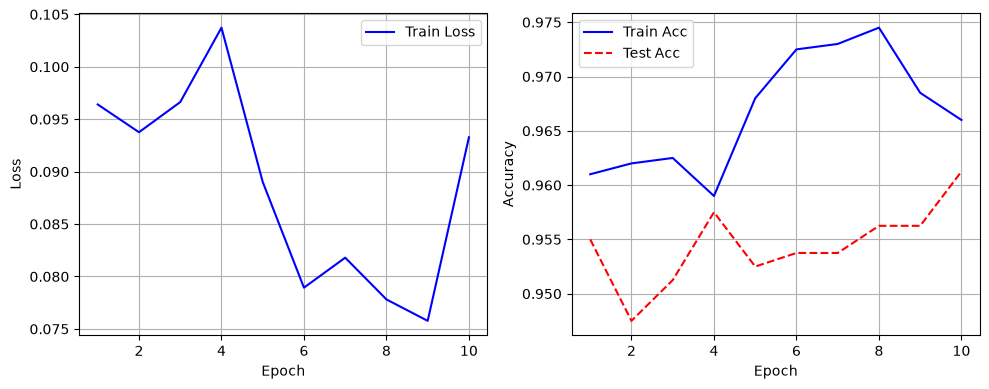

In [11]:
data_dir = r"C:\Users\17934\Desktop\MachineLearning\Program\DataSet\Figure\hotdog"

finetune_net = build_finetune_resnet18(num_classes=2, pretrained=True)

model_path = r"C:\Users\17934\Desktop\MachineLearning\Program\Computer_Vision\best_resnet18_cifar10.pth"
if os.path.exists(model_path):
    # 读取上次训练保存的最优模型权重
    checkpoint = torch.load(model_path, map_location="cpu")
    # 兼容多GPU训练产生的module.前缀，否则加载报错
    fixed_state = {k.replace("module.", ""): v for k, v in checkpoint.items()}
    finetune_net.load_state_dict(fixed_state)
    print(f"成功载入上次训练模型")
else:
    print(f"未找到历史模型文件")

history, best_acc = train_fine_tuning(
    net=finetune_net,
    data_dir=data_dir,
    learning_rate=1e-5,
    batch_size=32,
    num_epochs=10,
    param_group=True
)